<a href="https://colab.research.google.com/github/Sanjana-Munikrishnappa/ML_Saftey_Retrained/blob/ML-Saftey-Retrained/ML_Exercise_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Mount Google Drive
Mounts your Google Drive to the Colab environment, allowing access to files stored in your Drive.

In [ ]:
import google.colab.drive as gdrive

gdrive.mount("/content/drive")

Mounted at /content/drive


### Check for Zipped Dataset Files

Verifies the existence of the zipped dataset files (train.zip, validation.zip, test.zip) within the specified Google Drive path. This ensures that the necessary archives are available for extraction.

In [ ]:
from os.path import isfile

dataset_path = "/content/drive/MyDrive/carla_dataset"
files = ["train.zip", "validation.zip", "test.zip"]

for file_name in files:
    print(isfile(f"{dataset_path}/{file_name}"))

True
True
True


### Extract Dataset Files

Extracts the contents of the zipped dataset files into their respective directories within the Colab environment.

In [ ]:
from zipfile import ZipFile

base_path = "/content/drive/MyDrive/carla_dataset"

zip_files = {
    "train.zip": "train",
    "validation.zip": "validation",
    "test.zip": "test"
}

for archive_name, destination in zip_files.items():
    with ZipFile(f"{base_path}/{archive_name}", "r") as archive:
        archive.extractall(destination)

print("Dataset extraction completed successfully!")

Dataset extraction completed successfully!


### Verify Dataset Extraction

Prints the names of items within the 'train' directory after extraction, confirming successful extraction and file presence.

In [ ]:
from pathlib import Path

print([item.name for item in Path("train").iterdir()])

['train']


### Explore Extracted Folders

Iterates through the 'Train', 'Validation', and 'Test' folders and prints the first 5 filenames from each, providing a brief overview of dataset contents.

In [ ]:
from pathlib import Path

folders = {
    "Train": "train/train",
    "Validation": "validation/validation",
    "Test": "test/test"
}

for name, path in folders.items():
    print(f"{name} folder:")
    print([file.name for file in Path(path).iterdir()][:5])
    print()

Train folder:
['labels.feather', 'weather.feather', 'sim.log', 'labels.csv', '.hydra']

Validation folder:
['labels.feather', 'weather.feather', 'sim.log', 'labels.csv', '.hydra']

Test folder:
['labels.feather', 'weather.feather', 'sim.log', 'labels.csv', '.hydra']



### Loading Label Data

Loads the label data for training, validation, and test sets from Feather files into pandas DataFrames, then prints the number of samples in each.

In [ ]:
import pandas as pd

dataset_paths = {
    "Training": "train/train/labels.feather",
    "Validation": "validation/validation/labels.feather",
    "Test": "test/test/labels.feather"
}

label_data = {
    name: pd.read_feather(path)
    for name, path in dataset_paths.items()
}

for name, data in label_data.items():
    print(f"{name} samples:", len(data))

Training samples: 7200
Validation samples: 3600
Test samples: 3600


### Display Column Names

Displays the column names present in the training label DataFrame (`label_data["Training"]`), aiding in understanding available features and targets.

In [ ]:
print(list(label_data["Training"]))

['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle', 'px_traffic_light', 'px_pedestrian', 'px_vehicle']


### Analyze Label Distribution (Training Set)

Analyzes and prints the distribution of positive and negative samples for each target label in the training dataset, helping to understand class imbalance.

In [ ]:
labels = ["has_traffic_light", "has_pedestrian", "has_vehicle"]

train_df = label_data["Training"]

for label in labels:
    positive = (train_df[label] == 1).sum()
    negative = (train_df[label] == 0).sum()

    print(f"\n{label}")
    print("Positive:", positive)
    print("Negative:", negative)


has_traffic_light
Positive: 5276
Negative: 1924

has_pedestrian
Positive: 1718
Negative: 5482

has_vehicle
Positive: 5458
Negative: 1742


### Visualize Label Distribution

Generates bar plots to visually represent the distribution of positive and negative samples for each target label in the training dataset, showing class balance.

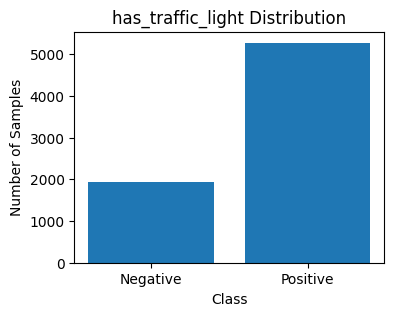

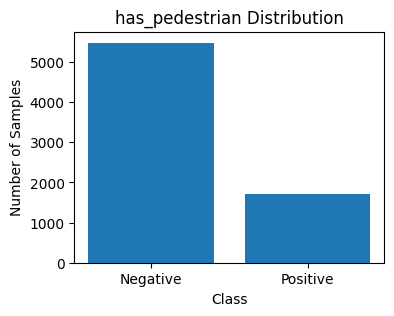

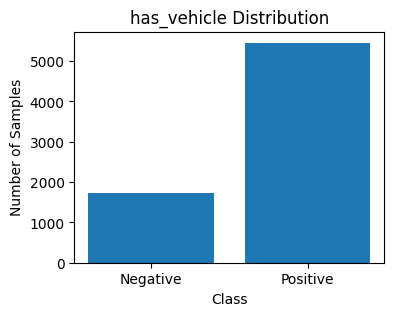

In [ ]:
import matplotlib.pyplot as plt

labels = ["has_traffic_light", "has_pedestrian", "has_vehicle"]

for label in labels:
    values = [
        (label_data["Training"][label] == 0).sum(),
        (label_data["Training"][label] == 1).sum()
    ]

    plt.figure(figsize=(4, 3))
    plt.bar(["Negative", "Positive"], values)
    plt.title(f"{label} Distribution")
    plt.xlabel("Class")
    plt.ylabel("Number of Samples")
    plt.show()

### Image Data Exploration

Explores image data by listing and counting image files in 'train/train/rgb-front' and displaying the first 5 images for visual inspection.

Number of images: 7200


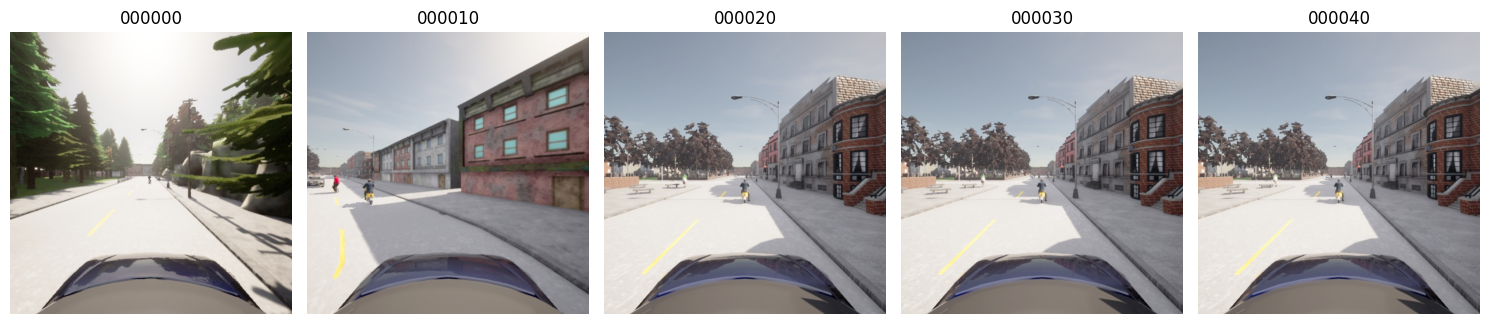

In [ ]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

image_directory = Path("train/train/rgb-front")

image_files = sorted(image_directory.iterdir())

print("Number of images:", len(image_files))

plt.figure(figsize=(15, 5))

for index, image_path in enumerate(image_files[:5], start=1):
    plt.subplot(1, 5, index)
    plt.imshow(Image.open(image_path))
    plt.axis("off")
    plt.title(image_path.stem[:10])

plt.tight_layout()
plt.show()

## Dataset and DataLoader Implementation

Defines and implements a custom PyTorch `Dataset` class for handling CARLA image and label data, and sets up `DataLoader` instances for training.

Image size: (500, 500)


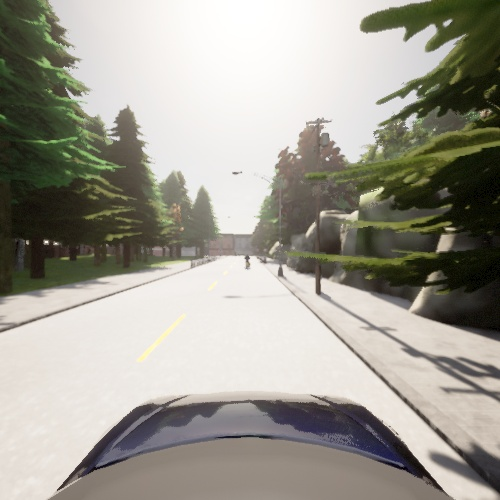

In [ ]:
from pathlib import Path
from PIL import Image

image_path = sorted(Path("train/train/rgb-front").glob("*"))[0]

sample = Image.open(image_path)

print("Image size:", sample.size)

sample

## Dataset and DataLoader Implementation

This section defines and implements a custom PyTorch `Dataset` class for handling the CARLA image and label data, along with setting up `DataLoader` instances for training.

In [ ]:
import torch
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image

class CarlaDataset(Dataset):

    def __init__(self, image_dir, annotations, target, transform=None):
        self.image_dir = Path(image_dir)
        self.annotations = annotations
        self.target = target
        self.transform = transform

    def __len__(self):
        return self.annotations.shape[0]

    def __getitem__(self, index):
        img_file = self.image_dir / f"{index:06d}.jpg"
        image = Image.open(img_file).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        label = torch.tensor(
            self.annotations.at[index, self.target],
            dtype=torch.float32
        )

        return image, label

### Initialize Image Transformations

Defines a `Compose` transformation sequence for image preprocessing, including resizing to 224x224 pixels and conversion to PyTorch tensors.

In [ ]:
from torchvision.transforms import Compose, Resize, ToTensor

transform = Compose([
    Resize((224, 224)),
    ToTensor()
])

print("Image transformations initialized successfully.")

Image transformations initialized successfully.


### Create Training Dataset Instance

Initializes an instance of the `CarlaDataset` for the training data, specifying image directory, annotations DataFrame, target label, and transformations.

In [ ]:
train_dataset = CarlaDataset(
    image_dir="train/train/rgb-front",
    annotations=label_data["Training"],
    target="has_traffic_light",
    transform=transform
)

print("Training samples:", len(train_dataset))

Training samples: 7200


### Create Training DataLoader

Creates a PyTorch `DataLoader` for the training dataset, configuring batching (size 32) and shuffling data for random sampling during training.

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True
)

print(f"Number of batches: {len(train_loader)}")

Number of batches: 225


### List Training Directory Contents

Lists all files and subdirectories within the 'train/train' folder, confirming the presence of necessary image folders and label files.

In [ ]:
from pathlib import Path

print([item.name for item in Path("train/train").iterdir()])

['labels.feather', 'weather.feather', 'sim.log', 'labels.csv', '.hydra', 'rgb-front', 'gnss.feather', 'actions.feather', 'segmentation-front', 'collisions.feather', 'imu.feather', 'carla.log']


### Display First 10 Image Filenames

Retrieves and prints the first 10 sorted filenames from the 'train/train/rgb-front' directory, useful for verifying naming conventions and order.

In [ ]:
from pathlib import Path

image_names = sorted(path.name for path in Path("train/train/rgb-front").iterdir())

print(image_names[:10])

['000000.jpg', '000010.jpg', '000020.jpg', '000030.jpg', '000040.jpg', '000050.jpg', '000060.jpg', '000070.jpg', '000080.jpg', '000090.jpg']


### Count Total Image Files

Counts and prints the total number of image files (`.jpg`) found in 'train/train/rgb-front', ensuring consistency with label data.

In [ ]:
from pathlib import Path

image_count = sum(1 for _ in Path("train/train/rgb-front").iterdir())

print("Number of files:", image_count)

Number of files: 7200


### Updated CarlaDataset (Fixing Indexing)

Redefines the `CarlaDataset` class to address potential indexing issues by storing sorted image paths and using `iloc` for label retrieval.

In [ ]:
import torch
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image

class CarlaDataset(Dataset):

    def __init__(self, image_dir, annotations, target, transform=None):
        self.image_dir = Path(image_dir)
        self.annotations = annotations
        self.target = target
        self.transform = transform
        self.images = sorted(self.image_dir.glob("*.jpg"))

    def __len__(self):
        return self.annotations.shape[0]

    def __getitem__(self, index):
        image = Image.open(self.images[index]).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        label = torch.tensor(
            self.annotations.iloc[index][self.target],
            dtype=torch.float32
        )

        return image, label

### Re-initialize Training Dataset with Fixed CarlaDataset

Re-initializes the `train_dataset` using the updated `CarlaDataset` class, ensuring corrected image indexing and label fetching logic.

In [ ]:
train_dataset = CarlaDataset(
    image_dir="train/train/rgb-front",
    annotations=label_data["Training"],
    target="has_traffic_light",
    transform=transform
)

### Re-create Training DataLoader (drop_last=False)

Re-creates the `train_loader` with the updated `train_dataset` and `drop_last=False`, ensuring all samples are used.

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True,
    drop_last=False
)

### Verify DataLoader Output

Fetches a single batch of images and labels from the `train_loader` and prints their tensor shapes, verifying correct data output.

In [ ]:
batch_images, batch_labels = next(iter(train_loader))

print("Image batch shape:", batch_images.size())
print("Label batch shape:", batch_labels.size())

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])


## Model Definition and Training (Traffic Light)

Defines the convolutional neural network model (`TrafficLightClassifier`), sets up the loss function and optimizer, and trains the model for traffic light classification.

In [ ]:
import torch.nn as nn

class TrafficLightClassifier(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

### Define TrafficLightClassifier Model

Defines the `TrafficLightClassifier` neural network, comprising a convolutional feature extractor and a fully connected classifier for binary image classification.

In [ ]:
network = TrafficLightClassifier()

print(network)

TrafficLightClassifier(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)


### Instantiate and Print Model Structure

Instantiates the `TrafficLightClassifier` model and prints its detailed architecture, useful for reviewing layers and parameters.

In [ ]:
import torch.nn as nn
from torch.optim import Adam

criterion = nn.BCEWithLogitsLoss()

optimizer = Adam(
    params=network.parameters(),
    lr=1e-3
)

print("Loss function and optimizer initialized successfully.")

Loss function and optimizer initialized successfully.


### Initialize Loss Function and Optimizer

Initializes `BCEWithLogitsLoss` as the loss function and Adam optimizer with a learning rate of `1e-3` for model training.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

network = network.to(device)

print(f"Using device: {device}")

Using device: cuda


### Set Device and Move Model

Determines the appropriate device (GPU if available, otherwise CPU) and moves the `network` model to it for hardware acceleration.

In [ ]:
epochs = 3

for epoch in range(epochs):

    network.train()
    total_loss = 0

    for batch_images, batch_labels in train_loader:

        batch_images = batch_images.to(device)
        batch_labels = batch_labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad(set_to_none=True)

        predictions = network(batch_images)

        loss = criterion(predictions, batch_labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch + 1}/{epochs}, Loss: {total_loss / len(train_loader):.4f}")

Epoch 1/3, Loss: 0.4379
Epoch 2/3, Loss: 0.2000
Epoch 3/3, Loss: 0.1210


### Prepare Validation Dataset and DataLoader

Prepares the validation dataset for traffic light detection using `CarlaDataset` and creates a `DataLoader` with `shuffle=False` for consistent evaluation.

In [ ]:
val_dataset = CarlaDataset(
    image_dir="validation/validation/rgb-front",
    annotations=label_data["Validation"],
    target="has_traffic_light",
    transform=transform
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=32,
    shuffle=False,
    drop_last=False
)

print(f"Validation samples: {len(val_dataset)}")

Validation samples: 3600


### Validation (Traffic Light)

This markdown cell introduces the validation phase for the Traffic Light Classifier model, where its performance will be evaluated on unseen data.

In [ ]:
network.eval()

matched = 0
sample_count = 0

with torch.inference_mode():

    for batch_images, batch_labels in val_loader:

        batch_images = batch_images.to(device)
        batch_labels = batch_labels.unsqueeze(1).float().to(device)

        logits = network(batch_images)

        predicted_labels = torch.sigmoid(logits).ge(0.5).float()

        sample_count += batch_labels.size(0)
        matched += predicted_labels.eq(batch_labels).sum().item()

validation_accuracy = (matched / sample_count) * 100

print(f"Validation Accuracy: {validation_accuracy:.2f}%")

Validation Accuracy: 95.94%


### Plot Traffic Light Training Loss

Plots the training loss for the `TrafficLightClassifier` over the training epochs, visualizing the model's learning progress.

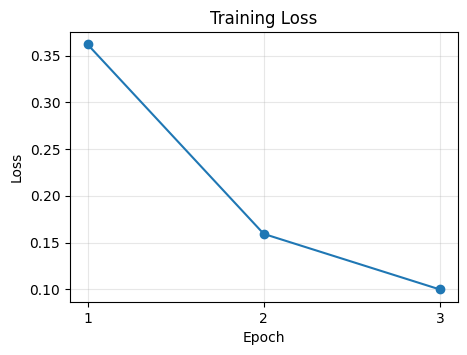

In [ ]:
import matplotlib.pyplot as plt

training_loss = [0.3618, 0.1593, 0.0999]
epoch_numbers = range(1, len(training_loss) + 1)

plt.figure(figsize=(5, 3.5))
plt.plot(epoch_numbers, training_loss, "-o")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epoch_numbers)
plt.grid(alpha=0.3)
plt.show()

### Initialize Pedestrian Training Dataset

Initializes a `CarlaDataset` instance specifically for training the pedestrian detection model, using 'has_pedestrian' as the target label.

In [ ]:
train_dataset_pedestrian = CarlaDataset(
    image_dir="train/train/rgb-front",
    annotations=label_data["Training"],
    target="has_pedestrian",
    transform=transform
)

### Create Pedestrian Training DataLoader

Creates a `DataLoader` for the pedestrian training dataset, configuring a batch size of 32 and shuffling data for effective training.

In [ ]:
from torch.utils.data import DataLoader

train_loader_pedestrian = DataLoader(
    dataset=train_dataset_pedestrian,
    batch_size=32,
    shuffle=True,
    drop_last=False
)

### Instantiate Pedestrian Model

Instantiates a new `TrafficLightClassifier` model, repurposed and moved to the device for pedestrian detection training.

In [ ]:
pedestrian_model = TrafficLightClassifier().to(device)

### Initialize Pedestrian Optimizer

Initializes the Adam optimizer for the `pedestrian_model` with a learning rate of `1e-3`, for updating weights during training.

In [ ]:
from torch.optim import Adam

optimizer_pedestrian = Adam(
    params=pedestrian_model.parameters(),
    lr=1e-3
)

### Train Pedestrian Model

Executes the training loop for the pedestrian detection model over 3 epochs, calculating and printing the average loss per epoch.

In [ ]:
epochs = 3

for epoch in range(epochs):

    pedestrian_model.train()
    total_loss = 0

    for batch_images, batch_labels in train_loader_pedestrian:

        batch_images = batch_images.to(device)
        batch_labels = batch_labels.unsqueeze(1).float().to(device)

        optimizer_pedestrian.zero_grad(set_to_none=True)

        predictions = pedestrian_model(batch_images)

        batch_loss = criterion(predictions, batch_labels)

        batch_loss.backward()

        optimizer_pedestrian.step()

        total_loss += batch_loss.item()

    average_loss = total_loss / len(train_loader_pedestrian)

    print(f"Epoch {epoch + 1}/{epochs}, Loss: {average_loss:.4f}")

Epoch 1/3, Loss: 0.5468
Epoch 2/3, Loss: 0.5068
Epoch 3/3, Loss: 0.4747


### Prepare Pedestrian Validation Dataset

Initializes a `CarlaDataset` for the validation set, targeting 'has_pedestrian' to prepare inputs for evaluating the pedestrian model.

In [ ]:
validation_path = "validation/validation/rgb-front"

val_dataset_pedestrian = CarlaDataset(
    image_dir=validation_path,
    annotations=label_data.get("Validation"),
    target="has_pedestrian",
    transform=transform
)

print("Validation samples:", val_dataset_pedestrian.__len__())

Validation samples: 3600


### Create Pedestrian Validation DataLoader

Creates a `DataLoader` for the pedestrian validation dataset with a batch size of 32 and disabled shuffling for consistent evaluation.

In [ ]:
from torch.utils.data import DataLoader

val_loader_pedestrian = DataLoader(
    dataset=val_dataset_pedestrian,
    batch_size=32,
    shuffle=False,
    drop_last=False
)

### Evaluate Pedestrian Model on Validation Set

Evaluates the trained `pedestrian_model` on the validation dataset, calculating and printing the overall accuracy of pedestrian detection.

In [ ]:
pedestrian_model.eval()

correct_predictions = 0
total_samples = 0

with torch.inference_mode():

    for batch_images, batch_labels in val_loader_pedestrian:

        batch_images = batch_images.to(device)
        batch_labels = batch_labels.unsqueeze(1).float().to(device)

        logits = pedestrian_model(batch_images)

        predicted = torch.sigmoid(logits).ge(0.5).float()

        total_samples += batch_labels.size(0)
        correct_predictions += predicted.eq(batch_labels).sum().item()

pedestrian_accuracy = (correct_predictions / total_samples) * 100

print(f"Pedestrian Validation Accuracy: {pedestrian_accuracy:.2f}%")

Pedestrian Validation Accuracy: 73.47%


### Initialize Vehicle Training Dataset

Initializes a `CarlaDataset` instance for the training set, specifically for vehicle detection, using 'has_vehicle' as the target.

In [ ]:
train_dataset_vehicle = CarlaDataset(
    image_dir="train/train/rgb-front",
    annotations=label_data["Training"],
    target="has_vehicle",
    transform=transform
)

### Create Vehicle Training DataLoader

Creates a `DataLoader` for the vehicle training dataset with a batch size of 32, shuffling data for randomized batches.

In [ ]:
from torch.utils.data import DataLoader

train_loader_vehicle = DataLoader(
    dataset=train_dataset_vehicle,
    batch_size=32,
    shuffle=True,
    drop_last=False
)

### Instantiate Vehicle Model

Instantiates and moves a new `TrafficLightClassifier` model to the device, adapting it for vehicle detection training.

In [ ]:
vehicle_model = TrafficLightClassifier().to(device)

### Initialize Vehicle Optimizer

Initializes the Adam optimizer for the `vehicle_model` with a `1e-3` learning rate, for adjusting model parameters during training.

In [ ]:
from torch.optim import Adam

optimizer_vehicle = Adam(
    params=vehicle_model.parameters(),
    lr=1e-3
)

### Train Vehicle Model

Performs the training loop for the vehicle detection model over 3 epochs, calculating and printing the average loss per epoch.

In [ ]:
epochs = 3

for epoch in range(epochs):

    vehicle_model.train()
    cumulative_loss = 0

    for batch_images, batch_labels in train_loader_vehicle:

        batch_images = batch_images.to(device)
        batch_labels = batch_labels.unsqueeze(1).float().to(device)

        optimizer_vehicle.zero_grad(set_to_none=True)

        predictions = vehicle_model(batch_images)

        loss_value = criterion(predictions, batch_labels)

        loss_value.backward()

        optimizer_vehicle.step()

        cumulative_loss += loss_value.item()

    mean_loss = cumulative_loss / len(train_loader_vehicle)

    print(f"Epoch {epoch + 1}/{epochs}, Loss: {mean_loss:.4f}")

Epoch 1/3, Loss: 0.5069
Epoch 2/3, Loss: 0.4282
Epoch 3/3, Loss: 0.3793


### Initialize Vehicle Validation Dataset

Initializes a `CarlaDataset` for the vehicle validation set, using 'has_vehicle' as the target for evaluation.

In [ ]:
validation_directory = "validation/validation/rgb-front"

val_dataset_vehicle = CarlaDataset(
    image_dir=validation_directory,
    annotations=label_data.get("Validation"),
    target="has_vehicle",
    transform=transform
)

print("Validation samples:", val_dataset_vehicle.__len__())

Validation samples: 3600


### Create Vehicle Validation DataLoader

Creates a `DataLoader` for the vehicle validation dataset with a batch size of 32 and disabled shuffling for deterministic evaluation.

In [ ]:
val_loader_vehicle = DataLoader(
    dataset=val_dataset_vehicle,
    batch_size=32,
    shuffle=False,
    drop_last=False
)

### Evaluate Vehicle Model on Validation Set

Evaluates the trained `vehicle_model` on the validation dataset, calculating and printing the overall accuracy of vehicle detection.

In [ ]:
vehicle_model.eval()

matched_predictions = 0
num_samples = 0

with torch.inference_mode():

    for batch_images, batch_labels in val_loader_vehicle:

        batch_images = batch_images.to(device)
        batch_labels = batch_labels.unsqueeze(1).float().to(device)

        logits = vehicle_model(batch_images)

        predicted_labels = torch.sigmoid(logits).ge(0.5).float()

        num_samples += batch_labels.size(0)
        matched_predictions += predicted_labels.eq(batch_labels).sum().item()

vehicle_accuracy = (matched_predictions / num_samples) * 100

print(f"Vehicle Validation Accuracy: {vehicle_accuracy:.2f}%")

Vehicle Validation Accuracy: 74.83%


## Training Loss Visualizations

Introduces the section for visualizing the training loss curves for each of the trained models.

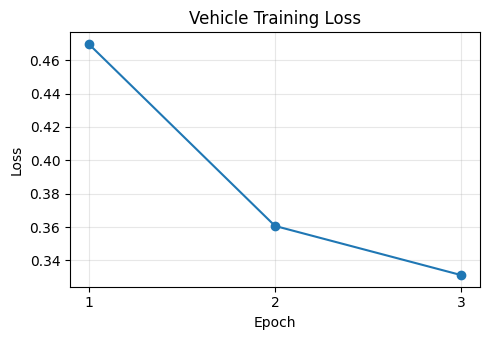

In [ ]:
import matplotlib.pyplot as plt

vehicle_loss = [0.4698, 0.3607, 0.3312]
epochs = list(range(1, len(vehicle_loss) + 1))

plt.figure(figsize=(5, 3.5))
plt.plot(epochs, vehicle_loss, "-o")
plt.title("Vehicle Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Plot Pedestrian Training Loss

Plots the training loss for the `pedestrian_model` over the training epochs, visualizing the learning progression and convergence.

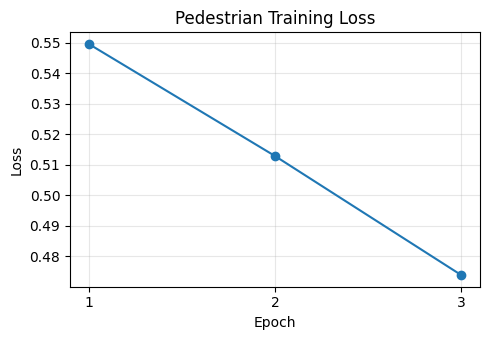

In [ ]:
import matplotlib.pyplot as plt

pedestrian_loss = [0.5497, 0.5129, 0.4738]
epoch_list = range(1, len(pedestrian_loss) + 1)

plt.figure(figsize=(5, 3.5))
plt.plot(epoch_list, pedestrian_loss, "-o")
plt.title("Pedestrian Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(list(epoch_list))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()